In [1]:
import os, sys

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.interpolate import UnivariateSpline
from scipy.signal import savgol_filter
sys.path.append("/Users/ana/Desktop/takarada")
import helpers_takarada as ht

plt.rcParams.update({'savefig.dpi':300, 'axes.labelweight':'normal'})
matplotlib.rcParams['axes.linewidth'] = 0.8
from matplotlib import rc
preamble = r'''\usepackage{physics} \usepackage{upgreek} \usepackage{bm}'''
plt.rc('text.latex', preamble=preamble)
rc('text', usetex=True)

plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['legend.fontsize'] = 12

def colorFader(c1, c2, mix=0.5):
    c1 = np.array(matplotlib.colors.to_rgb(c1))
    c2 = np.array(matplotlib.colors.to_rgb(c2))
    return matplotlib.colors.to_hex((1-mix)*c1 + mix*c2)

def get_palette_hex(palette_name, N):
    return sns.color_palette(palette_name, n_colors=N).as_hex()

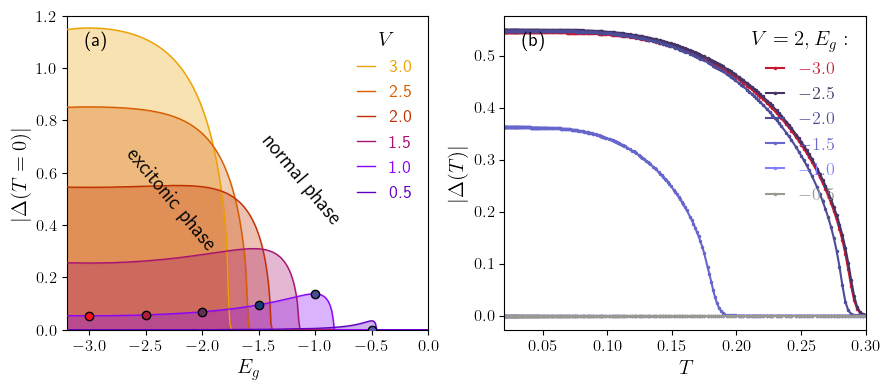

In [2]:
os.chdir('/Users/ana/Desktop/takarada/lips_data/03-03')
fig, ax = plt.subplots(ncols=2, figsize=(9,4))
Vbs = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
cols = get_palette_hex('gnuplot', len(Vbs))[::-1]
gaps_red = np.arange(-3.0, -0.0, 0.5)
Delta_bs_red = np.zeros((3, len(gaps_red)))

cols_red = get_palette_hex('gist_stern', len(gaps_red)+10)

for i, Vb in enumerate(Vbs[::-1]):
    data = np.load(f'data_Vb{Vb}.npz')

    Vb = data['Vb']
    gaps = data['gaps']
    Delta_bs = data['Delta_bs']
    Nk = data['Nk']

    if Vb in [1.0, 2.0, 3.0]:
        for j in range(len(gaps_red)):
            ind = np.argmin(np.abs(gaps - gaps_red[j]))
            Delta_bs_red[int(Vb) - 1,j] = Delta_bs[ind]
            if Vb==1.0:ax[0].scatter(gaps_red[j], Delta_bs_red[int(Vb) - 1,j], color=cols_red[j], zorder=1000000, edgecolor='black')
    ax[0].plot(gaps, Delta_bs, color=cols[i], lw=1, label=Vb, zorder=-1+10000)
    ax[0].fill_between(gaps, np.zeros(len(gaps)), Delta_bs, color=cols[i], alpha=0.3)

#ax.text(-2.1, 1.0, r'$V=3$', color=cols[-1], fontsize=13)
#ax.text(-1.8, 0.7, r'$V=2.5$', color=cols[-2], fontsize=13)
#ax.text(-1.5, 0.4, r'$V=2$', color=cols[-3], fontsize=13)
#ax.text(-1.2, 0.25, r'$V=1.5$', color=cols[-4], fontsize=13)
#ax.text(-0.8, 0.12, r'$V=1$', color=cols[-5], fontsize=13)
#ax.text(-0.4, 0.05, r'$V=1$', color=cols[-6], fontsize=13)


leg = ax[0].legend(frameon=False, loc='upper right', fontsize=13, handlelength=1)
leg.set_title(r'$V$', prop={'size':15})
for text, line in zip(leg.get_texts(), leg.get_lines()):
    text.set_color(line.get_color())
ax[0].set_xlim(-3.2,0)
ax[0].set_ylim(0,1.2)
ax[0].set_xlabel(r'$E_g$', fontsize=15)
ax[0].set_ylabel(r'$|\Delta(T=0)|$', fontsize=15)

ax[0].text(-2.7,0.3, r'excitonic phase', fontsize=15, zorder=100000, rotation=-50)
ax[0].text(-1.5, 0.4, r'normal phase', rotation=-50, fontsize=15)


Vbs = [1.0, 2.0, 3.0]
gaps = np.arange(-3.0, -0.0, 0.5)

Vb = 2.0
cols = get_palette_hex('gist_stern', len(gaps)+3)

for i, Vb in enumerate(Vbs):
    for j, gap in enumerate(gaps):
        data = np.load(f"temp-data_Vb{Vb:.1f}_gap{gap:.1f}.npz")
        Ts = data['Ts']
        delta_bs = data['delta_bs']
        Tc = Ts[np.abs(delta_bs) < 1e-3][0]

Vb = 2.0
for i, gap in enumerate(gaps):

    data = np.load(f"temp-data_Vb{Vb:.1f}_gap{gap:.1f}.npz")
    Ts = data['Ts']
    delta_bs = data['delta_bs']
    Tc = Ts[np.abs(delta_bs) < 1e-3][0]
    ax[1].plot(Ts, np.abs(delta_bs), '.-', color=cols[i], ms=3, lw=1.5, label=rf'${gap}$')
ax[1].set_xlim(0.02,0.3)
ax[1].set_xlabel(r'$T$', fontsize=15)
ax[1].set_ylabel(r'$|\Delta(T)|$', fontsize=15)

leg = ax[1].legend(frameon=False, loc='upper right', fontsize=13, handlelength=1)
leg.set_title(r'$V=2, E_g:$', prop={'size':15})
for text, line in zip(leg.get_texts(), leg.get_lines()):
    text.set_color(line.get_color())

ax[1].text(0.05, 0.95, r"(b)", transform=ax[1].transAxes,
            fontsize=14, va="top", ha="left")
ax[0].text(0.05, 0.95, r"(a)", transform=ax[0].transAxes,
            fontsize=14, va="top", ha="left")

plt.tight_layout()

os.chdir('/Users/ana/Desktop/takarada/slike')
plt.savefig('03-03-phdiag.pdf')

0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.005
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01


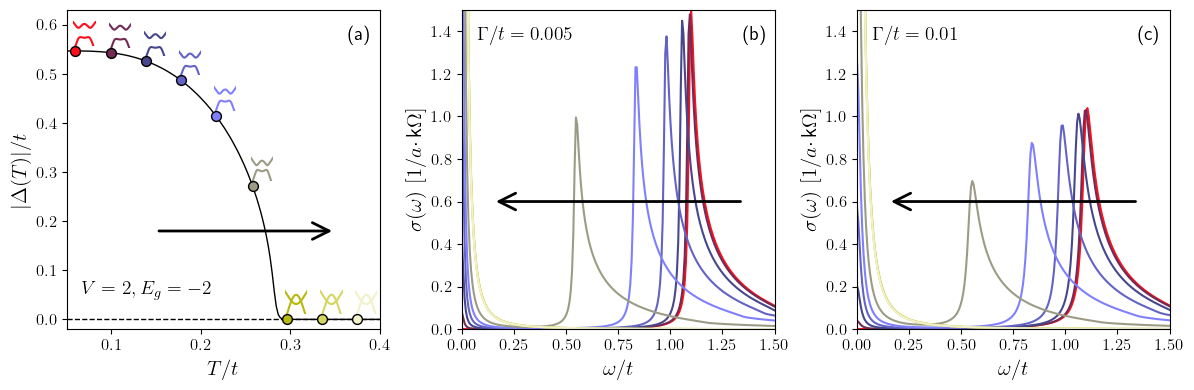

In [3]:
Nsteps = 17
Ngammas = 2
Nk = 3000
g = 1
eta = 0.0
omega_cut = 100

Vb = 2.0
gap = -2.0

os.chdir('/Users/ana/Desktop/takarada/lips_data/03-03')

data0 = np.load(f"temp-data_Vb{Vb:.1f}_gap{gap:.1f}.npz")

cols = get_palette_hex('gist_stern', Nsteps)

fig, ax = plt.subplots(ncols=3, figsize=(12,4))
predfaktor = 2 * np.pi  / 25.8
ax[0].plot(data0['Ts'], np.abs(data0['delta_bs']), color='black', lw=1)

Ts = []
gaps = []
for i in range(0,Nsteps,2):
    data = np.load(f"opt-data-03-03-Nk{Nk}-step{i}-gamma{g}.npz")
    Nk = data['Nk']
    Gamma = data['Gamma']
    print(Gamma)
    T = data['T']
    delta_b = data['delta_b']
    Ts.append(T)

    omegas = data['omegas']
    sigmas = data['sigmas']
    #time = data['time']
    #measurement = data['measurement']
    #pulz = data['pulz']

    energije = data['energije']
    gaps.append(np.min(energije[1]) - np.max(energije[0]))
    mu = 0.5 * (np.min(energije[1]) + np.max(energije[0]))
    K = 2*np.pi * np.arange(-Nk/2, Nk/2) / Nk
    #Omegas, Sigmas = ht.optical_conductivity(time, measurement[:,0].real, pulz, eta, omega_cut, Nk)

    ax[1].plot(omegas, sigmas * predfaktor, '-', color=cols[i])
    ax[0].scatter(T, np.abs(delta_b), color=cols[i], edgecolor='black', zorder=100, s=50, lw=1)

    ins = ax[0].inset_axes([T-0.002, np.abs(delta_b)+0.01, 0.025 ,0.055], transform=ax[0].transData)
    ins.plot(K, energije[0] - mu, color=cols[i])
    ins.plot(K, energije[1] - mu, color=cols[i])
    ins.set_xlim(-2.0,2.0)
    ins.set_ylim(-1.5,1.5)
    ins.axis('off')

g = 2

for i in range(0,Nsteps,2):
    data = np.load(f"opt-data-03-03-Nk{Nk}-step{i}-gamma{g}.npz")
    Nk = data['Nk']
    Gamma = data['Gamma']
    print(Gamma)
    T = data['T']
    delta_b = data['delta_b']

    omegas = data['omegas']
    sigmas = data['sigmas']

    #time = data['time']
    #measurement = data['measurement']
    #pulz = data['pulz']

    energije = data['energije']
    mu = 0.5 * (np.min(energije[1]) + np.max(energije[0]))

    ax[2].plot(omegas, sigmas * predfaktor, '-', color=cols[i])


ax[0].axhline(0, color='black', ls='dashed', lw=1)
ax[1].set_ylim(0,3.5)
#ax[1].set_xlim(0,0.5)
#ax[0].set_xlim(0.02,0.1)
#ax[0].set_ylim(-0.01,0.17)


ax[0].set_xlabel(r'$T/t$', fontsize=15)
ax[0].set_ylabel(r'$|\Delta(T)|/t$', fontsize=15)
ax[1].set_xlabel(r'$\omega/t$', fontsize=15)
ax[2].set_xlabel(r'$\omega/t$', fontsize=15)

ax[1].set_ylabel(r'$\sigma(\omega)\,\,[1/a\cdotp \text{k}\Omega]$', fontsize=15)
ax[2].set_ylabel(r'$\sigma(\omega)\,\,[1/a\cdotp \text{k}\Omega]$', fontsize=15)

data = np.load(f"temp-data_Vb{Vb:.1f}_gap{gap:.1f}.npz")

ax[0].annotate(
    "",                 # no text
    xy=(0.15, 0.18),           # arrow tip
    xytext=(0.35, 0.18),       # arrow tail
    arrowprops=dict(arrowstyle="<-", color='black', lw=2, mutation_scale=30)
)

ax[1].annotate(
    "",                 # no text
    xy=(1.35, 0.6),           # arrow tip
    xytext=(0.15, 0.6),       # arrow tail
    arrowprops=dict(arrowstyle="<-", color='black', lw=2, mutation_scale=30)
)
ax[2].annotate(
    "",                 # no text
    xy=(1.35, 0.6),           # arrow tip
    xytext=(0.15, 0.6),       # arrow tail
    arrowprops=dict(arrowstyle="<-", color='black', lw=2, mutation_scale=30)
)

ax[0].text(0.9, 0.95, r"(a)", transform=ax[0].transAxes,
            fontsize=14, va="top", ha="left")
ax[1].text(0.9, 0.95, r"(b)", transform=ax[1].transAxes,
            fontsize=14, va="top", ha="left")
ax[2].text(0.9, 0.95, r"(c)", transform=ax[2].transAxes,
            fontsize=14, va="top", ha="left")
ax[0].set_ylim(-0.02,0.63)
ax[0].set_xlim(0.05,0.4)

ax[1].set_xlim(0,1.5), ax[2].set_xlim(0,1.5)
ax[1].set_ylim(0,1.5), ax[2].set_ylim(0,1.5)

#ins = ax[0].inset_axes([0.1,0.2,0.3,0.3])
#ins.scatter(Ts, gaps, c=cols[::2])
ax[0].text(0.05, 0.15, r"$V=2, E_g=-2$", transform=ax[0].transAxes,
            fontsize=14, va="top", ha="left")
ax[1].text(0.05, 0.95, r"$\Gamma/t=0.005$", transform=ax[1].transAxes,
            fontsize=14, va="top", ha="left")
ax[2].text(0.05, 0.95, r"$\Gamma/t=0.01$", transform=ax[2].transAxes,
            fontsize=14, va="top", ha="left")

plt.tight_layout()

os.chdir('/Users/ana/Desktop/takarada/slike')
plt.savefig('03-03-opt.pdf')

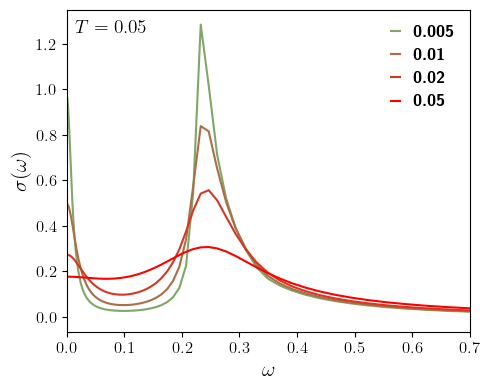

In [4]:
Nk = 3000
steps = np.arange(6)
Gammas = [0.005, 0.01, 0.02, 0.05]
omegas = np.logspace(-4,1,200)
predfaktor = 2 * np.pi  / 25.8

fig, ax = plt.subplots(ncols=1, figsize=(5,4))
cols2 = sns.color_palette("ch:0.0, r=1, l=0.9, d=0.1", len(steps))

os.chdir('/Users/ana/Desktop/takarada/lips_data/30-01-phdiag')
Vb = 1.
gap = -1.
data = np.load(f"data_Vb{Vb}_gap{gap}.npz")
Ts = data['Ts']
deltas = data['delta_bs']
os.chdir('/Users/ana/Desktop/takarada/lips_data/06-02-phdiag')
Ts_ = []
for i, step in enumerate(steps):
    for g, Gamma in enumerate(Gammas):
        results = np.load(f"dataopt_06-02-Nk{Nk}-step{i}-gamma{g}.npz")
        T = results["T"]
        if g==0: Ts_.append(T)
        delta = results["delta"]
        chi_jj = results["j_j"]
        sigma = chi_jj.imag / omegas
        if i==2:
            ax.plot(omegas, sigma * predfaktor, color=colorFader(cols2[i], 'red', g / (len(Gammas) - 1)), label=f"\\textbf{{{Gamma}}}") 
ax.set_xlim(0,0.7)
ax.set_xlabel(r'$\omega$', fontsize=15)
ax.set_ylabel(r'$\sigma(\omega)$', fontsize=15)

leg = ax.legend(frameon=False, fontsize=12, handlelength=0.5)

ax.text(0.02, 0.97, rf"$T={np.round(Ts_[2],2)}$", transform=ax.transAxes,
            fontsize=14, va="top", ha="left")

plt.tight_layout()


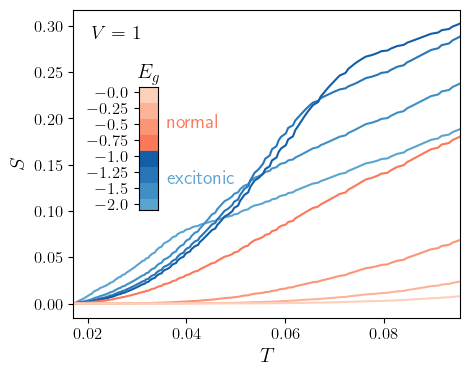

In [5]:
os.chdir('/Users/ana/Desktop/takarada/lips_data/30-01-phdiag')

gaps = [-2.0, -1.5, -1.25, -1.0, -0.75, -0.5, -0.25, -0.0]
pal  = get_palette_hex('Blues', 10)
pal2 = get_palette_hex('Reds', 10)[::-1]

Vb = 1.
Nk = 2000

fig, ax = plt.subplots(ncols=1,  figsize=(5,4))

ins = ax.inset_axes([0.17, 0.35, 0.05, 0.4])

for g, gap in enumerate(gaps[:-4]):
    col = pal[g+5]
    data = np.load(f"data_Vb{Vb}_gap{gap}.npz")
    Ts = data['Ts']
    deltas = data['delta_bs']
    mean_energies = data['mean_energies']
    L11 = data['L11_boltz']
    L12 = data['L12_boltz']
    n0s = data['ns0']
    n1s = data['ns1']
    #gaps = data['gaps']

    mean_energies_smooth = savgol_filter(
    mean_energies,
    window_length=40,   # increase if needed
    polyorder=3)
    Cv = np.gradient(mean_energies_smooth, Ts)
    S = np.zeros(len(Ts))
    for i, T in enumerate(Ts):
        S[i] = np.trapezoid(Cv[:i].real / Ts[:i], Ts[:i])

    ax.plot(Ts, S, color=col)
    ins.axhline(g, color=col, lw=15)

for g, gap in enumerate(gaps[4:]):
    col = pal2[g+5]
    data = np.load(f"data_Vb{Vb}_gap{gap}.npz")
    Ts = data['Ts']
    deltas = data['delta_bs']
    mean_energies = data['mean_energies']
    L11 = data['L11_boltz']
    L12 = data['L12_boltz']
    n0s = data['ns0']
    n1s = data['ns1']
    #gaps = data['gaps']

    mean_energies_smooth = savgol_filter(
    mean_energies,
    window_length=40,   # increase if needed
    polyorder=3)
    Cv = np.gradient(mean_energies_smooth, Ts)
    S = np.zeros(len(Ts))
    for i, T in enumerate(Ts):
        S[i] = np.trapezoid(Cv[:i].real / Ts[:i], Ts[:i])

    ax.plot(Ts, S, color=col)
    ins.axhline(g+4, color=col, lw=15)

ins.set_yticks(np.arange(len(gaps)))
ins.set_yticklabels([rf'${g}$' for g in gaps])
ins.set_xticks([])
ins.set_title(r'$E_g$', fontsize=15)
ax.set_xlabel(r'$T$', fontsize=15)
ax.set_ylabel(r'$S$', fontsize=15)
ax.set_xlim(Ts[0], Ts[-1])

ax.text(0.036, 0.19, 'normal', color=pal2[5], fontsize=14)
ax.text(0.036, 0.13, 'excitonic', color=pal[5], fontsize=14)

ax.text(0.05, 0.95, r"$V=1$", transform=ax.transAxes,
            fontsize=14, va="top", ha="left")

os.chdir('/Users/ana/Desktop/takarada/slike')
plt.savefig('03-03-entropy.pdf')


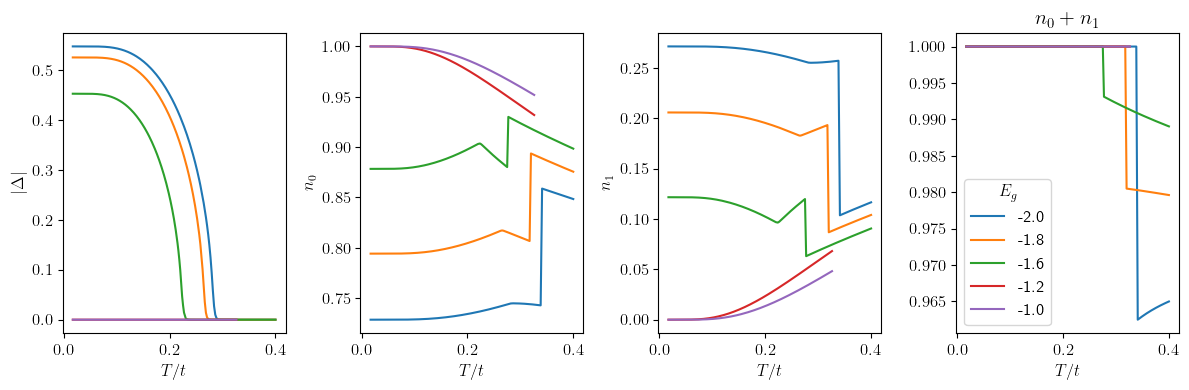

In [6]:
os.chdir('/Users/ana/Desktop/takarada/lips_data/03-03')
predfaktor = 2 * np.pi  / 25.8

Vb = 2.0
gaps = [-2.0, -1.8, -1.6, -1.2, -1.0]
fig, ax = plt.subplots(ncols=4, figsize=(12,4))
for g, gap in enumerate(gaps):
    data = np.load(f"DC-Nk2000-data_Vb{Vb:.1f}_gap{gap:.1f}.npz")
    Ts = data['Ts']
    deltas = data['delta_bs']
    mean_energies = data['mean_energies']
    L11 = data['L11_boltz']
    L12 = data['L12_boltz']
    L22 = data['L22_boltz']
    n0s = data['ns0']
    n1s = data['ns1']
    gaps = data['gaps']

    l11 = data['L11']
    l12 = data['L12']
    l22 = data['L22']
    energies = data['mean_energies']
    mus = data['mus']

    Cv = np.gradient(energies, Ts)

    S = np.zeros(len(Ts))
    for i, T in enumerate(Ts):
        S[i] = np.trapezoid(Cv[:i].real / Ts[:i], Ts[:i])

    l12_smooth = savgol_filter(
        l12[:,0],
        window_length=10,   # increase if needed
        polyorder=3)

    l11_smooth = savgol_filter(
        l11[:,0],
        window_length=10,   # increase if needed
        polyorder=3)
    
    S = np.zeros(len(Ts))
    for i, T in enumerate(Ts):
        S[i] = np.trapezoid(Cv[:i].real / Ts[:i], Ts[:i])

    ax[0].plot(Ts, np.abs(deltas))
    ax[1].plot(Ts, n0s, label=gap)
    ax[2].plot(Ts, n1s, label=gap)
    ax[3].plot(Ts, n0s + n1s, label=gap)

for j in range(4):
    ax[j].set_xlabel(r'$T/t$')

ax[3].legend().set_title(r'$E_g$', prop={'size' : 12})  
ax[1].set_ylabel(r'$n_0$')
ax[2].set_ylabel(r'$n_1$')
ax[0].set_ylabel(r'$|\Delta|$')
ax[3].set_title(r'$n_0 + n_1$')
plt.tight_layout()

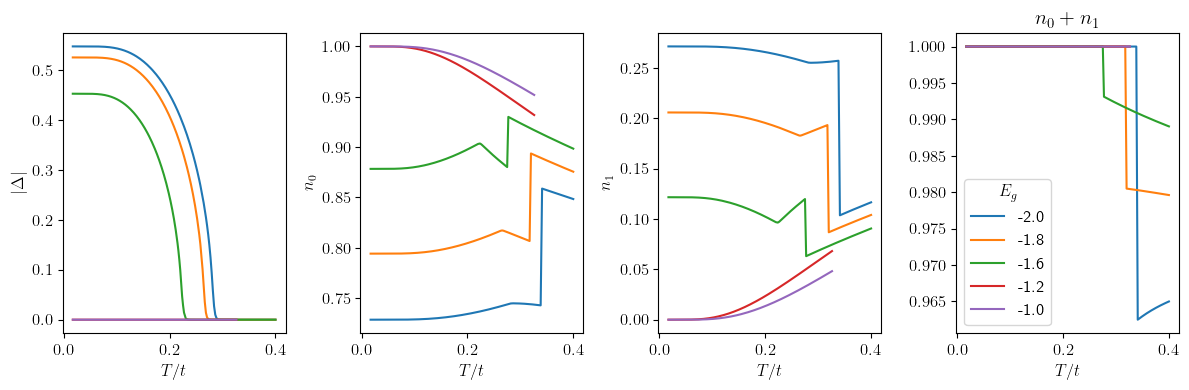

In [7]:
os.chdir('/Users/ana/Desktop/takarada/lips_data/03-03')
predfaktor = 2 * np.pi  / 25.8

Vb = 2.0
gaps = [ -2.0, -1.8, -1.6, -1.2, -1.0]
fig, ax = plt.subplots(ncols=4, figsize=(12,4))
for g, gap in enumerate(gaps):
    data = np.load(f"DC-Nk2000-data_Vb{Vb:.1f}_gap{gap:.1f}.npz")
    Ts = data['Ts']
    deltas = data['delta_bs']
    mean_energies = data['mean_energies']
    L11 = data['L11_boltz']
    L12 = data['L12_boltz']
    L22 = data['L22_boltz']
    n0s = data['ns0']
    n1s = data['ns1']
    gaps = data['gaps']

    l11 = data['L11']
    l12 = data['L12']
    l22 = data['L22']
    energies = data['mean_energies']
    mus = data['mus']

    Cv = np.gradient(energies, Ts)

    S = np.zeros(len(Ts))
    for i, T in enumerate(Ts):
        S[i] = np.trapezoid(Cv[:i].real / Ts[:i], Ts[:i])

    l12_smooth = savgol_filter(
        l12[:,0],
        window_length=10,   # increase if needed
        polyorder=3)

    l11_smooth = savgol_filter(
        l11[:,0],
        window_length=10,   # increase if needed
        polyorder=3)
    
    S = np.zeros(len(Ts))
    for i, T in enumerate(Ts):
        S[i] = np.trapezoid(Cv[:i].real / Ts[:i], Ts[:i])

    ax[0].plot(Ts, np.abs(deltas))
    ax[1].plot(Ts, n0s, label=gap)
    ax[2].plot(Ts, n1s, label=gap)
    ax[3].plot(Ts, n0s + n1s, label=gap)

for j in range(4):
    ax[j].set_xlabel(r'$T/t$')

ax[3].legend().set_title(r'$E_g$', prop={'size' : 12})  
ax[1].set_ylabel(r'$n_0$')
ax[2].set_ylabel(r'$n_1$')
ax[0].set_ylabel(r'$|\Delta|$')
ax[3].set_title(r'$n_0 + n_1$')
plt.tight_layout()

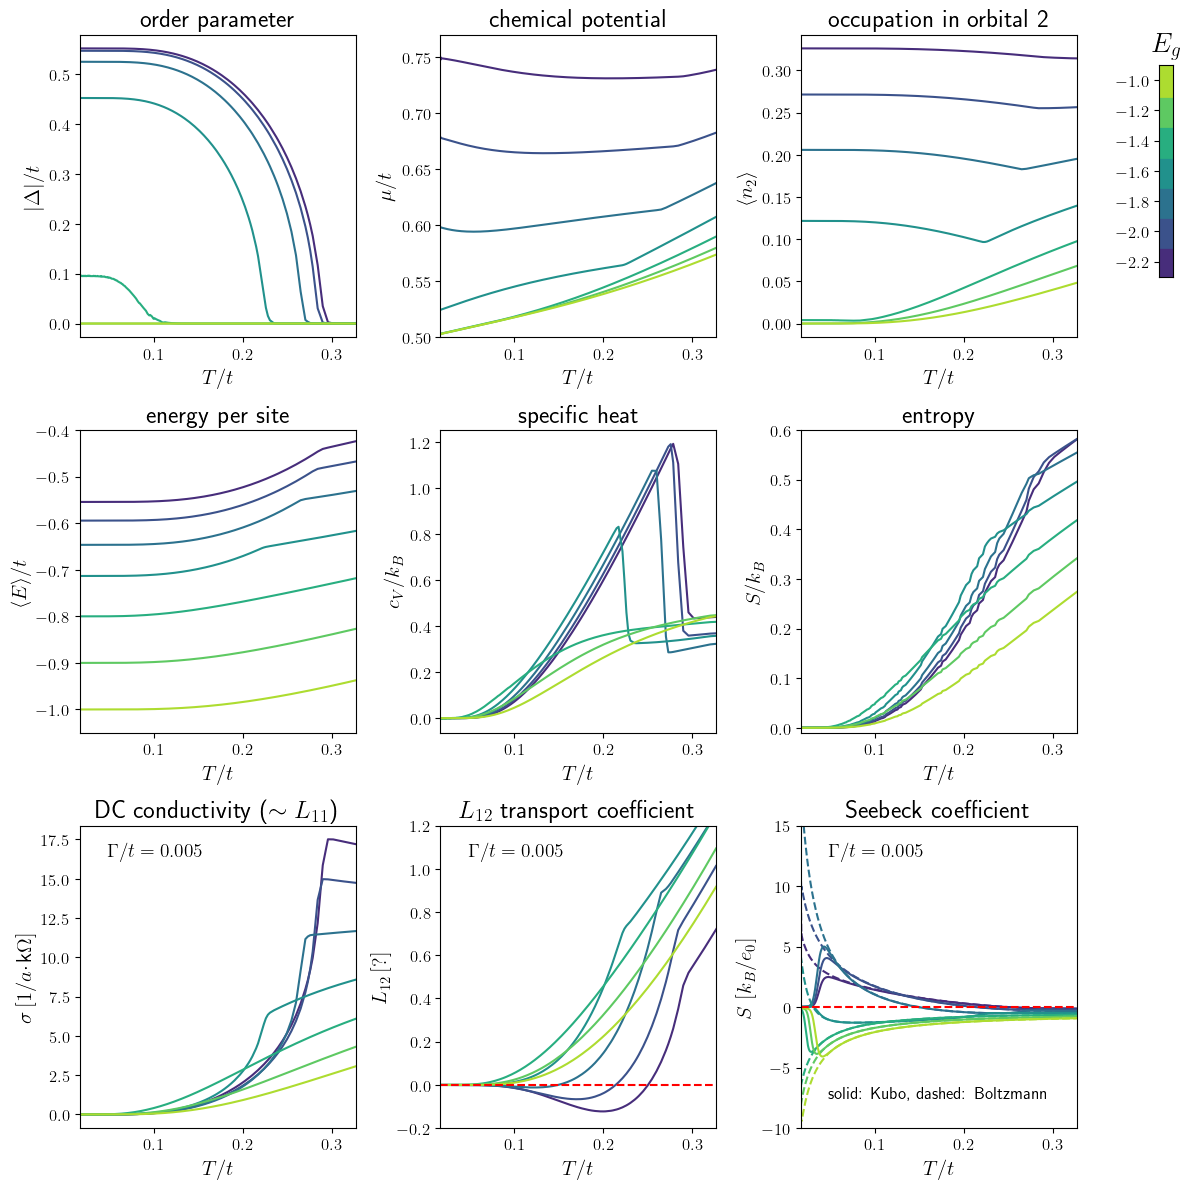

In [27]:
os.chdir('/Users/ana/Desktop/takarada/lips_data/03-03')
predfaktor = 2 * np.pi  / 25.8
Gammas = [0.001, 0.005, 0.01, 0.02]
Vb = 2.0
Gaps = [-2.2, -2.0, -1.8, -1.6, -1.4, -1.2, -1.0]
cols = get_palette_hex('viridis', len(Gaps))
fig, ax = plt.subplots(ncols=3, nrows=3, figsize=(12,12))
maxTs = []
minTs = []
ins = ax[0,2].inset_axes([1.3,0.2,0.05,0.7])
for g, gap in enumerate(Gaps):
    data = np.load(f"DCreverse-Nk2000-data_Vb{Vb:.1f}_gap{gap:.1f}.npz")
    Ts = data['Ts']
    maxTs.append(max(Ts)), minTs.append(min(Ts))
    deltas = data['delta_bs']
    mean_energies = data['mean_energies']
    L11 = data['L11_boltz']
    L12 = data['L12_boltz']
    L22 = data['L22_boltz']
    n0s = data['ns0']
    n1s = data['ns1']
    gaps = data['gaps']

    l11 = data['L11']
    l12 = data['L12']
    l22 = data['L22']
    energies = data['mean_energies']
    mus = data['mus']

    Cv = np.gradient(energies, Ts)

    S = np.zeros(len(Ts))
    for i, T in enumerate(Ts):
        S[i] = np.trapezoid(Cv[:i].real / Ts[:i], Ts[:i])

    l12_smooth = savgol_filter(
        l12[:,0],
        window_length=10,   # increase if needed
        polyorder=3)

    l11_smooth = savgol_filter(
        l11[:,0],
        window_length=10,   # increase if needed
        polyorder=3)
    
    S = np.zeros(len(Ts))
    for i, T in enumerate(Ts):
        S[i] = np.trapezoid(Cv[:i].real / Ts[:i], Ts[:i])

    colg = cols[g]
    ax[0,0].plot(Ts, np.abs(deltas), color=colg)
    ax[0,1].plot(Ts, mus, color=colg)
    #ax[0,2].plot(Ts, n0s, color=colg)
    ax[0,2].plot(Ts, n1s, color=colg)

    ax[1,0].plot(Ts, energies, color=colg)
    ax[1,1].plot(Ts, Cv, color=colg)
    ax[1,2].plot(Ts, S, color=colg)

    ax[2,0].plot(Ts, l11[:,1] * predfaktor, color=colg)
    ax[2,1].plot(Ts, l12[:,1] * predfaktor, color=colg)
    ax[2,2].plot(Ts, -l12[:,1] / l11[:,1] / Ts, color=colg)

    ax[2,2].plot(Ts, -L12[:,1] / L11[:,1] / Ts, color=colg, ls='dashed')
    ins.axhline(g, color=colg, lw=25)
    #plt.plot(Ts, np.abs(deltas))

for j in range(3):
    for i in range(3):
        ax[i,j].set_xlabel(r'$T/t$', fontsize=15)
        ax[i,j].set_xlim(max(minTs), min(maxTs))
    
ins.set_xticks([])
ins.set_yticks(range(len(Gaps)))
ins.set_ylim(-0.5,len(Gaps) - 0.5)
ins.set_yticklabels([rf'${u}$' for u in Gaps])
ins.set_title(r'$E_g$', fontsize=20, pad=10)
ax[0,0].set_ylabel(r'$|\Delta|/t$', fontsize=15)
ax[0,1].set_ylabel(r'$\mu/t$', fontsize=15),ax[0,1].set_ylim(0.5, 0.77)
ax[0,2].set_ylabel(r'$\expval{n_2}$', fontsize=15)
ax[1,0].set_ylabel(r'$\langle{E\rangle}/t$', fontsize=15), ax[1,0].set_ylim(-1.05, -0.4)
ax[1,1].set_ylabel(r'$c_V/k_B$', fontsize=15)
ax[1,2].set_ylabel(r'$S/k_B$', fontsize=15), ax[1,2].set_ylim(-0.01,0.6)
ax[2,0].set_ylabel(r'$\sigma\,[1/a\cdotp \text{k}\Omega]$', fontsize=15)
ax[2,1].set_ylabel(r'$L_{12}\,[?]$', fontsize=15), ax[2,1].set_ylim(-0.2,1.2), ax[2,1].axhline(0.0, ls='dashed', color='red')
ax[2,2].set_ylabel(r'$S\,\,[k_B/e_0]$', fontsize=15), ax[2,2].axhline(0.0, ls='dashed', color='red')

fs = 18
ax[0,0].set_title(r'order parameter', fontsize=fs)
ax[0,1].set_title(r'chemical potential', fontsize=fs)
ax[0,2].set_title(r'occupation in orbital 2', fontsize=fs)
ax[1,0].set_title(r'energy per site', fontsize=fs)
ax[1,1].set_title(r'specific heat', fontsize=fs)
ax[1,2].set_title(r'entropy', fontsize=fs)
ax[2,0].set_title(r'DC conductivity ($\sim L_{11}$)', fontsize=fs)
ax[2,1].set_title(r'$L_{12}$ transport coefficient', fontsize=fs)
ax[2,2].set_title(r'Seebeck coefficient', fontsize=fs)
ax[2,2].set_ylim(-10,15)

for j in range(3):
    ax[2,j].text(0.1,0.9, rf'$\Gamma/t={Gammas[1]}$', transform=ax[2,j].transAxes, fontsize=14)
ax[2,2].text(0.1,0.1, rf'solid: Kubo, dashed: Boltzmann', transform=ax[2,2].transAxes, fontsize=12)

plt.tight_layout()
os.chdir('/Users/ana/Desktop/takarada/slike')
plt.savefig('03-03-observables.pdf')


In [8]:
'''
        data = {"delta_bs": np.array(self.delta_bs),
                "delta_cs": np.array(self.delta_cs),
                "ns0": np.array(self.ns0),
                "ns1": np.array(self.ns1),
                "gaps": np.array(self.gaps),
                "mus": np.array(self.mus),
                "errors": np.array(self.errors),
                "occupations": np.array(self.occupations),
                "Ts": np.array(self.Ts),
                "mean_energies": np.array(self.mean_energies),
                "L11": np.array(self.L11),
                "L12": np.array(self.L12),
                "L22" : np.array(self.L22),
                "L12q": np.array(self.L12q),
                "L11_boltz": np.array(self.L11_boltz),
                "L12_boltz": np.array(self.L12_boltz),
                "L22_boltz": np.array(self.L22_boltz),
                "L11_0": np.array(self.L11_0),
                "L11_corr": np.array(self.L11_corr),
                "L12_0": np.array(self.L12_0),
                "L12_corr": np.array(self.L12_corr),
                "L12q_0": np.array(self.L12q_0),
                "L12q_corr": np.array(self.L12q_corr),
                "phys_parameters" : np.array(self.phys_parameters),
                "Gammas": self.Gammas}

'''

'\n        data = {"delta_bs": np.array(self.delta_bs),\n                "delta_cs": np.array(self.delta_cs),\n                "ns0": np.array(self.ns0),\n                "ns1": np.array(self.ns1),\n                "gaps": np.array(self.gaps),\n                "mus": np.array(self.mus),\n                "errors": np.array(self.errors),\n                "occupations": np.array(self.occupations),\n                "Ts": np.array(self.Ts),\n                "mean_energies": np.array(self.mean_energies),\n                "L11": np.array(self.L11),\n                "L12": np.array(self.L12),\n                "L22" : np.array(self.L22),\n                "L12q": np.array(self.L12q),\n                "L11_boltz": np.array(self.L11_boltz),\n                "L12_boltz": np.array(self.L12_boltz),\n                "L22_boltz": np.array(self.L22_boltz),\n                "L11_0": np.array(self.L11_0),\n                "L11_corr": np.array(self.L11_corr),\n                "L12_0": np.array(self.L12_0),